# Vision Transformer from Scratch (PyTorch)

Implementation of the Vision Transformer (Dosovitskiy et al., 2020), building
the attention mechanism from "Attention Is All You Need" (Vaswani et al., 2017)
from scratch. Trained on CIFAR-10 from scratch: 84.4% test accuracy.

Note: from-scratch ViT on a small dataset scores below pretrained ViT/ResNet
(~93%) by design — ViTs lack CNNs' spatial inductive bias and are data-hungry.
This project prioritizes understanding the architecture over peak accuracy.

## Scaled Dot-Product Attention

Computes attention as softmax(QKᵀ / √dₖ)·V. The scores QKᵀ are divided
by √dₖ before softmax — without this, large dot products push softmax
into saturated regions where gradients vanish, making training unstable.
The √dₖ scaling keeps the softmax gradients healthy.


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
DATA_ROOT = '/content/drive/MyDrive/cifar10_data'
os.makedirs(DATA_ROOT, exist_ok=True)
print("Data will be saved to:", DATA_ROOT)
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import math
import torch
import torch.nn.functional as F
import math

def scaled_dot_product(Q,K,V,mask=None):
  """
  args
  Q : (batch,seq_len,d_k)
  K : (batch,seq_len,d_k)
  V : (batch,seq_len,d_k)
  mask : (batch,seq_len_q,seq_len_k) - for decode masking
  returns:
  o/p = (batch,seq_len_q,d_v)
  attn_weights = (batch,seq_len_q,seq_len_k) for inspection

  """
  d_k = Q.shape[-1]
  scores = torch.matmul(Q,K.transpose(-2,-1))
  scores = scores/d_k**0.5
  if mask is not None:
    scores =scores.masked_fill(mask==0,float('-inf'))

  att_weights = F.softmax(scores,dim=-1)
  output = torch.matmul(att_weights,V)

  return output, att_weights




Mounted at /content/drive
Data will be saved to: /content/drive/MyDrive/cifar10_data


## Multi-Head Attention

Runs several attention "heads" in parallel, each with its own learned
Q, K, V projections. Different heads can attend to different relationships
in the input. The heads' outputs are concatenated and projected back to
d_model by W_O. Validated against PyTorch's nn.MultiheadAttention
(max difference ~1e-07).

In [3]:
import torch.nn as nn
class MultiheadAttention(nn.Module):
  def __init__(self,d_model,h):
    super().__init__()
    assert d_model % h==0 # d must be divisble by h means the remaninder should be 0

    self.d_model =d_model
    self.h=h
    self.d_k = d_model//h
    self.W_Q = nn.Linear(d_model,d_model, bias = False)
    self.W_K = nn.Linear(d_model,d_model, bias = False)
    self.W_V = nn.Linear(d_model,d_model, bias = False)
    self.W_O = nn.Linear(d_model,d_model, bias = False)
  def forward(self,Q,K,V,mask = None):
    B = Q.shape[0]
    Q = self.W_Q(Q)
    K = self.W_K(K)
    V = self.W_V(V)
    # Split heads
    Q = Q.view(B,-1,self.h,self.d_k).transpose(1,2)
    K = K.view(B,-1,self.h,self.d_k).transpose(1,2)
    V = V.view(B,-1,self.h,self.d_k).transpose(1,2)
    # attention on each head
    x,att_weights = scaled_dot_product(Q,K,V,mask)
    # concatenate
    x= x.transpose(1,2).contiguous().view(B,-1,self.d_model)
    output = self.W_O(x)

    return output, att_weights



## Positional Encoding

Attention is permutation-invariant — on its own it has no notion of token
order. Positional encodings add order information to each token's embedding
so the model knows the sequence position of each patch.

In [4]:
class PositionalEncoding(nn.Module):
  def __init__(self,d_model,max_seq_len=5000):
    super().__init__()
    #create a matrix of shape
    pe = torch.zeros(max_seq_len,d_model)
    #postional indices unsqeeze makes it column vector easy for division
    position = torch.arange(0,max_seq_len).unsqueeze(1).float()

    div_term = torch.exp(
        torch.arange(0,d_model,2).float()*(-math.log(10000)/d_model)
    )

    #apply sin
    pe[:,0::2]= torch.sin(position*div_term)
    pe[:,1::2]= torch.cos(position*div_term)

    pe = pe.unsqueeze(0)
    # saves inside model pe but never learnable
    self.register_buffer('pe',pe)

  def forward(self,x):
      x =x+self.pe[:, :x.shape[1], :]
      return x



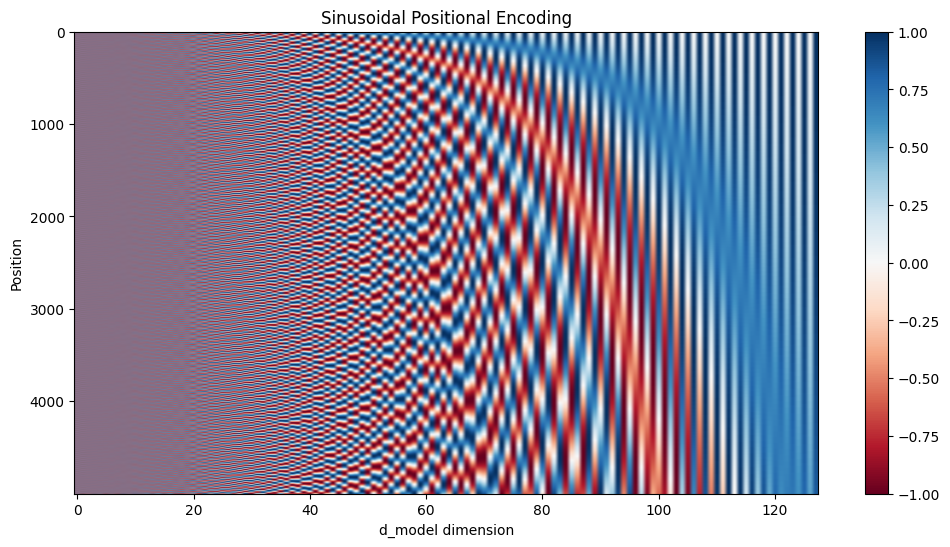

In [5]:
import matplotlib.pyplot as plt

# Instantiate PositionalEncoding
pe = PositionalEncoding(d_model=128, max_seq_len=5000)

plt.figure(figsize =(12,6))
plt.imshow(pe.pe[0].numpy(), aspect='auto', cmap='RdBu')
plt.colorbar()
plt.xlabel("d_model dimension")
plt.ylabel("Position")
plt.title("Sinusoidal Positional Encoding")
plt.show()

## Feed-Forward Network

A position-wise MLP applied to each token independently:
- Linear(d_model → d_ff)
→ ReLU → Linear(d_ff → d_model).
- Expands to a higher dimension, applies a
non-linearity, then projects back. Here d_ff = 512, d_model = 256.

## Encoder Block

Combines multi-head attention and the feed-forward network, each wrapped
with a LayerNorm and a residual connection (pre-norm: norm → sublayer → add).
Stacking N of these blocks forms the transformer encoder.

In [6]:
class FeedForward(nn.Module):
  def __init__(self,d_model,d_ff):
    super().__init__()
    self.linear1= nn.Linear(d_model,d_ff)
    self.linear2= nn.Linear(d_ff,d_model)
    self.relu =nn.ReLU()

  def forward(self,x):
    return self.linear2(self.relu(self.linear1(x)))

class EncoderBlock(nn.Module):
  def __init__(self,d_model,h,d_ff,dropout =0.1):
    super().__init__()
    self.attention = MultiheadAttention(d_model,h)
    self.ff = FeedForward (d_model,d_ff)
    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.dropout = nn.Dropout(dropout)

  def forward(self,x,mask =None):
    attn_output,_ = self.attention(x,x,x,mask)
    x=self.norm1(x+self.dropout(attn_output))
    ff_output = self.ff(x)
    x =self.norm2(x+self.dropout(ff_output))
    return x


## Patch Embedding

Splits the image into fixed-size patches and linearly projects each into a
d_model-dimensional token. A 32×32 image with 4×4 patches gives 64 patches,
each 4×4×3 = 48 raw values, projected to d_model = 256.

## Vision Transformer (ViT)

Full model: patch embedding → positional encoding → N encoder blocks →
final LayerNorm → classification head. Trained from scratch on CIFAR-10,
reaching 84.4% test accuracy (d_model=256, 6 layers, 8 heads).

In [7]:

class PatchEmbedding(nn.Module):
  def __init__(self,img_size,patch_size,in_channels,d_model):
    super().__init__()
    self.patch_size= patch_size #4
    self.n_patches = (img_size//patch_size)**2 #32//4**2 = 64
    self.projection = nn.Linear(patch_size*patch_size*in_channels,d_model)

  def forward(self,x):
    B,C,H,W = x.shape
    P = self.patch_size
    x = x.reshape(B,C,H//P,P,W//P,P)
    x = x.permute(0,2,4,1,3,5)
    x = x.reshape(B,-1,C*P*P)
    x= self.projection(x)
    return x

class ViT(nn.Module):
  def __init__(self,img_size,patch_size,in_channels,d_model,h,d_ff,n_layers,n_classes, dropout=0.1):
    super().__init__()
    self.patch_embed= PatchEmbedding(img_size,patch_size,in_channels,d_model)
    n_patches =(img_size//patch_size)**2

    self.cls_token = nn.Parameter(torch.zeros(1,1,d_model))
    self.pos_embed = nn.Parameter(torch.zeros(1,n_patches+1,d_model))

    self.encoder_blocks = nn.ModuleList([
        EncoderBlock(d_model,h,d_ff,dropout)
        for _ in range(n_layers)
    ])

    self.norm = nn.LayerNorm(d_model)
    self.classifier  = nn.Linear(d_model,n_classes)
    self.Dropout = nn.Dropout(dropout)
  def forward(self,x):
    B = x.shape[0]
    x =self.patch_embed(x)
    cls =self.cls_token.expand(B,-1,-1)
    x=torch.cat([cls,x],dim =1)
    x = self.Dropout(x+ self.pos_embed)
    for blocks in self.encoder_blocks:
      x= blocks(x)
    x= self.norm(x[:, 0,:])
    return self.classifier(x)


## Training and evalution on CIFAR10 Dataset

In [14]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
# ── Data ───────────────────────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True,
                                              download=True, transform=transform_train)
test_dataset  = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=False,
                                              download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2)


# ── Model, Loss, Optimizer ─────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = ViT(
    img_size=32, patch_size=4, in_channels=3,
    d_model=128, h=4, d_ff=256, n_layers=6,
    n_classes=10, dropout=0.3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)


# ── Training & Evaluation Functions ───────────────────────────────
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total


# ── Training Loop ─────────────────────────────────────────────────
for epoch in range(30):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc   = evaluate(model, test_loader, criterion, device)
    scheduler.step()
    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.1f}% | "
          f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.1f}%")

Using device: cuda
Epoch 01 | Train Loss: 1.896 | Train Acc: 28.5% | Test Loss: 1.694 | Test Acc: 36.6%
Epoch 02 | Train Loss: 1.595 | Train Acc: 41.0% | Test Loss: 1.417 | Test Acc: 49.1%
Epoch 03 | Train Loss: 1.412 | Train Acc: 48.5% | Test Loss: 1.314 | Test Acc: 52.0%
Epoch 04 | Train Loss: 1.318 | Train Acc: 52.0% | Test Loss: 1.221 | Test Acc: 55.7%
Epoch 05 | Train Loss: 1.266 | Train Acc: 54.1% | Test Loss: 1.176 | Test Acc: 57.6%
Epoch 06 | Train Loss: 1.215 | Train Acc: 56.0% | Test Loss: 1.126 | Test Acc: 59.5%
Epoch 07 | Train Loss: 1.178 | Train Acc: 57.3% | Test Loss: 1.155 | Test Acc: 57.3%
Epoch 08 | Train Loss: 1.151 | Train Acc: 58.6% | Test Loss: 1.111 | Test Acc: 59.7%
Epoch 09 | Train Loss: 1.112 | Train Acc: 59.8% | Test Loss: 1.074 | Test Acc: 61.0%
Epoch 10 | Train Loss: 1.087 | Train Acc: 60.6% | Test Loss: 1.027 | Test Acc: 62.8%
Epoch 11 | Train Loss: 1.062 | Train Acc: 61.7% | Test Loss: 1.010 | Test Acc: 63.8%
Epoch 12 | Train Loss: 1.041 | Train Acc: 62.4

In [10]:
# Bigger model - enough capacity to reach 80%
model2 = ViT(
    img_size=32, patch_size=4, in_channels=3,
    d_model=256, h=8, d_ff=512, n_layers=6,
    n_classes=10, dropout=0.1
).to(device)

criterion2 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=50, eta_min=1e-6)

for epoch in range(50):
    train_loss, train_acc = train(model2, train_loader, optimizer2, criterion2, device)
    test_loss, test_acc   = evaluate(model2, test_loader, criterion2, device)
    scheduler2.step()
    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.1f}% | "
          f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.1f}%")

Epoch 01 | Train Loss: 1.859 | Train Acc: 35.5% | Test Loss: 1.601 | Test Acc: 48.8%
Epoch 02 | Train Loss: 1.520 | Train Acc: 52.8% | Test Loss: 1.426 | Test Acc: 56.6%
Epoch 03 | Train Loss: 1.406 | Train Acc: 58.2% | Test Loss: 1.328 | Test Acc: 62.2%
Epoch 04 | Train Loss: 1.328 | Train Acc: 61.9% | Test Loss: 1.287 | Test Acc: 64.9%
Epoch 05 | Train Loss: 1.272 | Train Acc: 64.9% | Test Loss: 1.233 | Test Acc: 67.3%
Epoch 06 | Train Loss: 1.231 | Train Acc: 67.0% | Test Loss: 1.211 | Test Acc: 67.8%
Epoch 07 | Train Loss: 1.196 | Train Acc: 68.4% | Test Loss: 1.168 | Test Acc: 69.9%
Epoch 08 | Train Loss: 1.163 | Train Acc: 70.0% | Test Loss: 1.162 | Test Acc: 70.2%
Epoch 09 | Train Loss: 1.133 | Train Acc: 71.5% | Test Loss: 1.099 | Test Acc: 73.0%
Epoch 10 | Train Loss: 1.109 | Train Acc: 72.5% | Test Loss: 1.091 | Test Acc: 73.8%
Epoch 11 | Train Loss: 1.079 | Train Acc: 73.9% | Test Loss: 1.082 | Test Acc: 74.5%
Epoch 12 | Train Loss: 1.058 | Train Acc: 74.9% | Test Loss: 1.04

In [11]:
import torch
import torch.nn as nn

torch.manual_seed(42)  # fix seed so both models get identical weights

B, seq_len, d_model, h = 2, 5, 128, 4

# ──  implementation ────────────────────────────────────────────
my_mha = MultiheadAttention(d_model, h)

# ── PyTorch's official implementation ─────────────────────────────
pytorch_mha = nn.MultiheadAttention(
    embed_dim=d_model,
    num_heads=h,
    bias=False,
    batch_first=True   # makes input (B, seq, d_model) same as yours
)

# PyTorch stores Q, K, V weights as one combined matrix (in_proj_weight)
# My implementation stores them separately as W_Q, W_K, W_V
with torch.no_grad():
    # Stack your Q, K, V weights into one matrix
    pytorch_mha.in_proj_weight.copy_(
        torch.cat([my_mha.W_Q.weight, my_mha.W_K.weight, my_mha.W_V.weight], dim=0)
    )
    # Copy output projection
    pytorch_mha.out_proj.weight.copy_(my_mha.W_O.weight)

# ── Run both on identical input ────────────────────────────────────
x = torch.randn(B, seq_len, d_model)

output, _ = my_mha(x, x, x)
pytorch_output, _ = pytorch_mha(x, x, x)

# ── Compare ────────────────────────────────────────────────────────
print("output shape:    ", output.shape)
print("PyTorch output shape: ", pytorch_output.shape)
print("Max difference:       ", (output - pytorch_output).abs().max().item())
print("Outputs match:        ", torch.allclose(output, pytorch_output, atol=1e-5))

output shape:     torch.Size([2, 5, 128])
PyTorch output shape:  torch.Size([2, 5, 128])
Max difference:        1.7881393432617188e-07
Outputs match:         True
